# Laboratorio de clustering — dataset *Wine*
Aplicamos clustering (jerárquico y PAM / k-medoids) al dataset **Wine** de scikit-learn: 178 vinos descritos por 13 variables químicas, provenientes de 3 cultivares distintos. Como conocemos la clase real de cada vino, podremos usarla como **validación externa** de los grupos que encontremos.

In [ ]:
# Detección de entorno (para instalar dependencias solo en Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules

In [ ]:
# Gráficos
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8,6)
plt.rcParams['font.size'] = 16
import seaborn as sns

# Números y Datos
import numpy as np
import pandas as pd
pd.set_option('future.infer_string', False)

# Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
df = pd.DataFrame(data = wine.data, columns = wine.feature_names)
df["label"] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
df.label.unique()

array([0, 1, 2])

In [ ]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

Vamos a dejar los targets aparte para no afectar el clustering

In [ ]:
labels_target = df.label
df = df.drop(columns=['label'])

In [ ]:
df.shape

(178, 13)

In [ ]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [ ]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [ ]:
if IN_COLAB:
    !pip install -q gower
import gower

## Matriz de distancias
Todas las variables son numéricas, pero en escalas muy distintas (p. ej. `proline` vale cientos/miles y `flavanoids` entre 0 y 5). Usamos la **distancia de Gower**, que normaliza cada variable por su rango antes de combinarlas. Una alternativa equivalente y muy habitual para datos puramente numéricos es **estandarizar** (media 0, desvío 1) y usar distancia **euclídea**; sin escalar, una sola variable de magnitud grande dominaría la distancia.

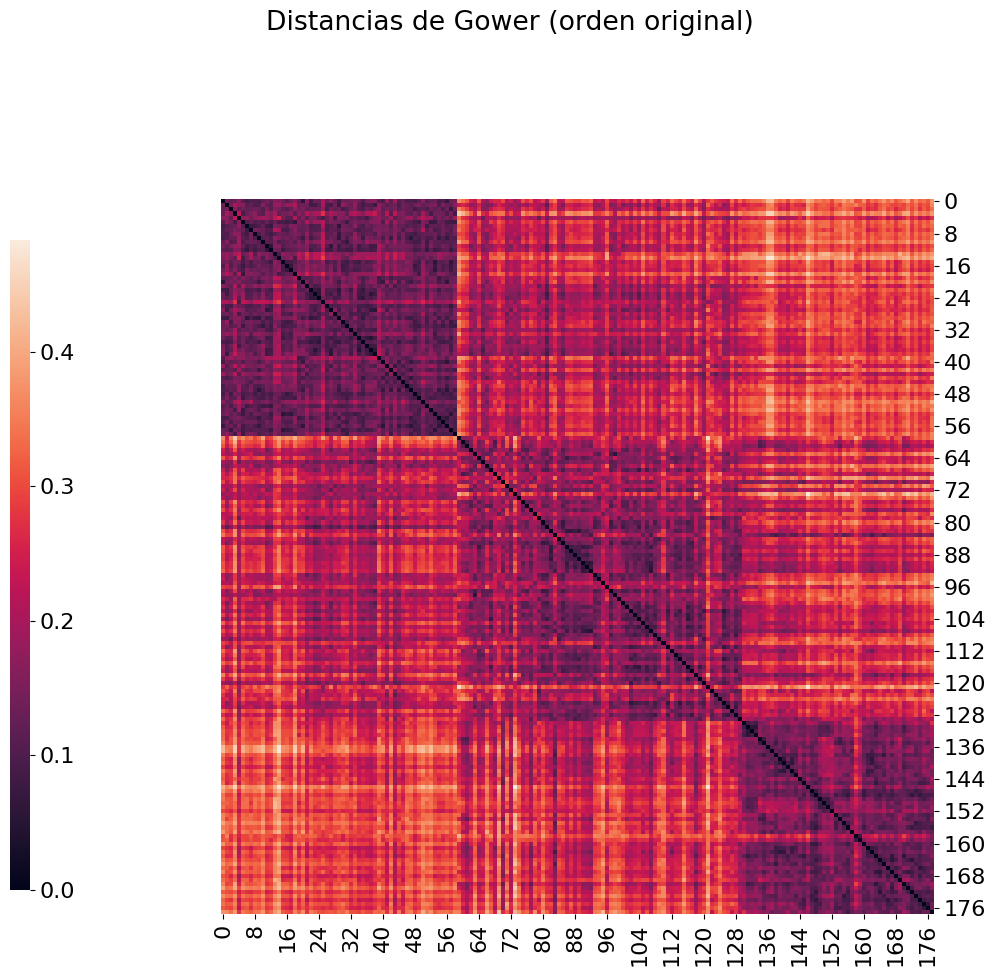

In [ ]:
d_wine = gower.gower_matrix(df)
g = sns.clustermap(d_wine, row_cluster=False, col_cluster=False, cbar_pos=(0, .1, .02, .65))
plt.suptitle('Distancias de Gower (orden original)')

plt.show()

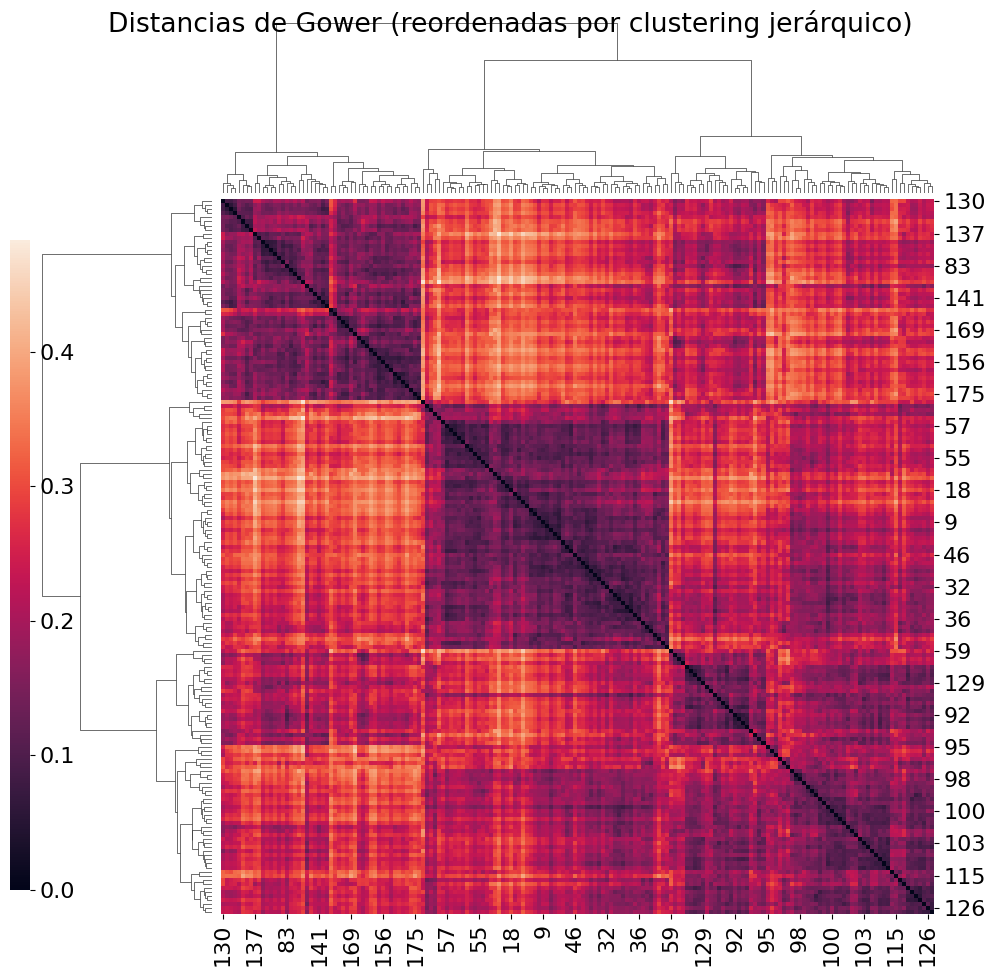

In [ ]:
# Le pasamos un linkage precomputado para que el reordenamiento use las distancias de Gower
# (y no la euclídea entre perfiles de distancia, que es lo que clustermap haría por defecto).
Z_wine = linkage(squareform(d_wine), method='ward')
g = sns.clustermap(d_wine, row_linkage=Z_wine, col_linkage=Z_wine, cbar_pos=(0, .1, .02, .65))
plt.suptitle('Distancias de Gower (reordenadas por clustering jerárquico)')
plt.show()

## Clustering jerárquico
Construimos un dendrograma con linkage de Ward sobre las distancias de Gower y lo cortamos para obtener las etiquetas `labels_jer`.

In [ ]:
from scipy.cluster.hierarchy import cophenet, fcluster

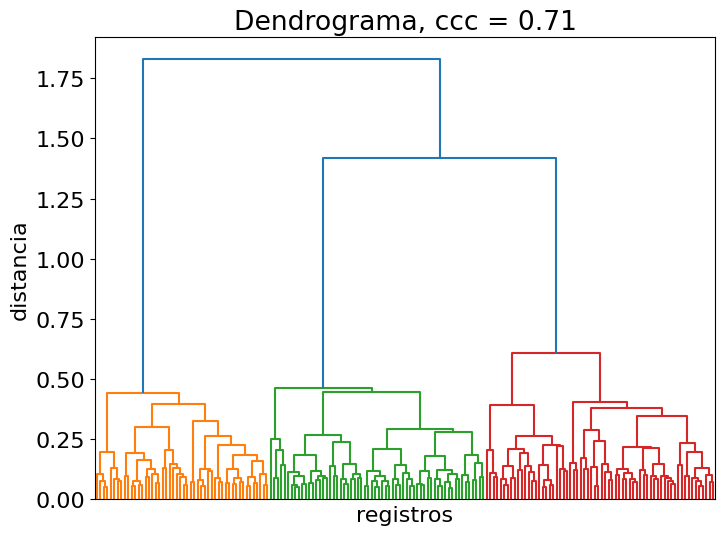

In [ ]:
# Z_wine ya se calculó arriba con 'ward'. Se pueden probar otros linkages: 'single', 'average', 'complete'.
c, _ = cophenet(Z_wine, Y=squareform(d_wine))
plt.title('Dendrograma, ccc = %0.2f' % c)
plt.xlabel('registros')
plt.ylabel('distancia')
dn = dendrogram(Z_wine, no_labels=True)

In [ ]:
th = 0.7 * max(Z_wine[:, 2])  # columna con las distancias
labels_jer = fcluster(Z_wine, th, criterion='distance')

print("Threshold:", th)
print("Etiquetas de los clusters:", labels_jer)

Threshold: 1.279931313805713
Etiquetas de los clusters: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 1 2 3 2
 3 3 3 3 3 3 3 3 3 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


## PAM (k-medoids)
Agrupamos con PAM (FasterPAM) sobre la misma matriz de distancias y buscamos un buen valor de *k* con las curvas de SSE y silhouette.

In [ ]:
if IN_COLAB:
    !pip install -q kmedoids
from kmedoids import KMedoids
from sklearn.metrics import silhouette_samples, silhouette_score

In [ ]:
def calcula_sse_kmedoids(KM,d):
  # Suma de distancias AL CUADRADO a cada medoide (estilo SSE de k-means). Nota: el objetivo
  # que PAM realmente minimiza es la suma de disimilitudes SIN elevar al cuadrado (KM.inertia_).
  se = []
  for i in range(0,KM.n_clusters):
    se.append(sum(d[KM.medoid_indices_[i],KM.labels_==i]**2))
  return sum(se)

In [ ]:
KM = KMedoids(n_clusters=3, metric='precomputed', method='fasterpam',
              init='build', random_state=0).fit(d_wine)

In [ ]:
print(KM.labels_)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 2 0 1 0 0 2 0 2
 2 0 0 0 0 2 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 2 0
 0 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [ ]:
df.iloc[KM.medoid_indices_]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
106,12.25,1.73,2.12,19.0,80.0,1.65,2.03,0.37,1.63,3.40,1.00,3.17,510.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0
35,13.48,1.81,2.41,20.5,100.0,2.70,2.98,0.26,1.86,5.10,1.04,3.47,920.0


In [ ]:
labels_target.iloc[KM.medoid_indices_]

,label
106,1
148,2
35,0


In [ ]:
print(f"Silhouette score: {silhouette_score(d_wine,KM.labels_,metric='precomputed')}")
print(f"SSE: {calcula_sse_kmedoids(KM,d_wine)}")

print("Silhouette samples:", silhouette_samples(d_wine,KM.labels_,metric='precomputed')[:40], "...")

Silhouette score: 0.31185972690582275
SSE: 2.8318238258361816
Silhouette samples: [0.48909864 0.31890517 0.4356931  0.46627566 0.21662298 0.48480392
 0.4382608  0.4187685  0.41909012 0.47262034 0.4716985  0.31665406
 0.42358688 0.3550571  0.43711272 0.44809237 0.45553195 0.40994954
 0.43191174 0.3995806  0.4461277  0.20799538 0.403336   0.22464348
 0.2676838  0.14865313 0.4009308  0.18656021 0.3977354  0.40065786
 0.43266112 0.4639     0.2844967  0.33874938 0.33073336 0.41258118
 0.29243258 0.21806033 0.15755849 0.3883294 ] ...


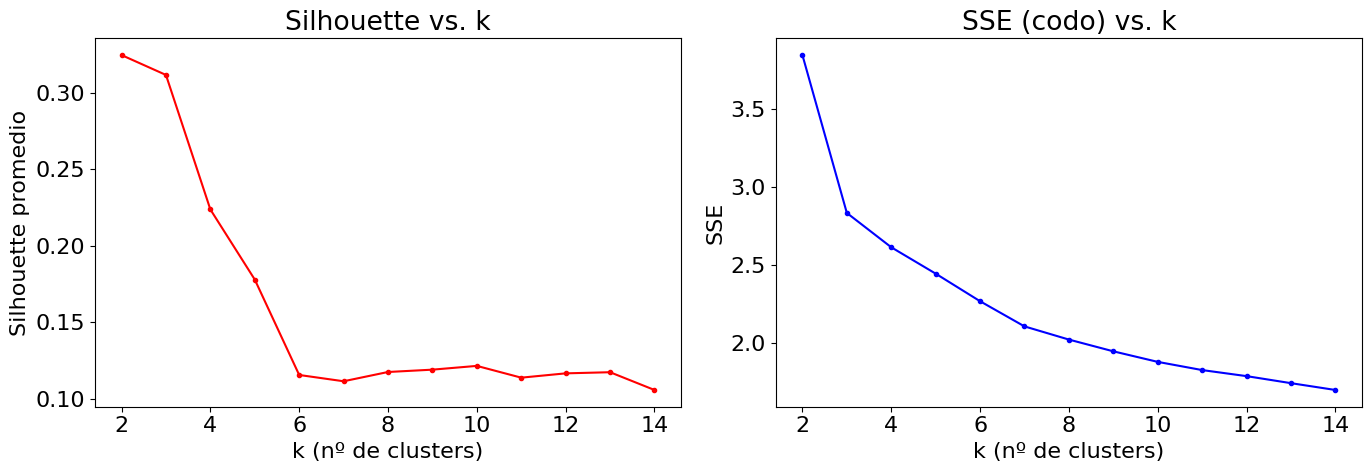

In [ ]:
range_k = list(range(2, 15))
silh, sse = [], []
for k in range_k:
    KM = KMedoids(n_clusters=k, metric='precomputed', method='fasterpam',
                  init='build', random_state=0).fit(d_wine)
    silh.append(silhouette_score(d_wine, KM.labels_, metric='precomputed'))
    sse.append(calcula_sse_kmedoids(KM, d_wine))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range_k, silh, 'r.-'); ax1.set_xlabel('k (nº de clusters)')
ax1.set_ylabel('Silhouette promedio'); ax1.set_title('Silhouette vs. k')
ax2.plot(range_k, sse, 'b.-'); ax2.set_xlabel('k (nº de clusters)')
ax2.set_ylabel('SSE'); ax2.set_title('SSE (codo) vs. k')
plt.tight_layout(); plt.show()

#### ¿Cómo se interpretan estos gráficos?

Ayuda: mirar el cluster jerárquico que hicimos antes.

Probamos primero con k=3.

#Función para graficar silouette

In [ ]:
def grafica_silhouette(KM,d):
  # Derivamos k del propio modelo en lugar de depender de una variable global 'k'.
  k = KM.n_clusters
  cmap = plt.get_cmap('nipy_spectral')
  silhouette_avg = silhouette_score(d,KM.labels_,metric='precomputed')
  sample_silhouette_values = silhouette_samples(d,KM.labels_,metric='precomputed')

  plt.rcParams['figure.figsize'] = (8,6)
  plt.xlim([-0.25, 1])
  plt.ylim([0, len(KM.labels_) + (k + 1) * 10])

  y_lower = 10
  for i in range(k):
      ith_cluster_silhouette_values = sample_silhouette_values[KM.labels_ == i]

      ith_cluster_silhouette_values.sort()

      size_cluster_i = ith_cluster_silhouette_values.shape[0]
      y_upper = y_lower + size_cluster_i

      color = cmap(float(i) / k)
      plt.fill_betweenx(np.arange(y_lower, y_upper),
                        0, ith_cluster_silhouette_values,
                        facecolor=color, edgecolor=color, alpha=0.7)

      plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

      y_lower = y_upper + 10

  plt.title("Análisis de silhouette para clustering con k = %d" % k,
                fontsize=14, fontweight='bold')
  plt.xlabel("Coeficiente de silhouette")
  plt.ylabel("Etiquetas de cluster")

  # La línea vertical marca el coeficiente de silhouette promedio
  plt.axvline(x=silhouette_avg, color="red", linestyle="--")

  plt.yticks([])  # Clear the yaxis labels / ticks
  plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
  plt.show()

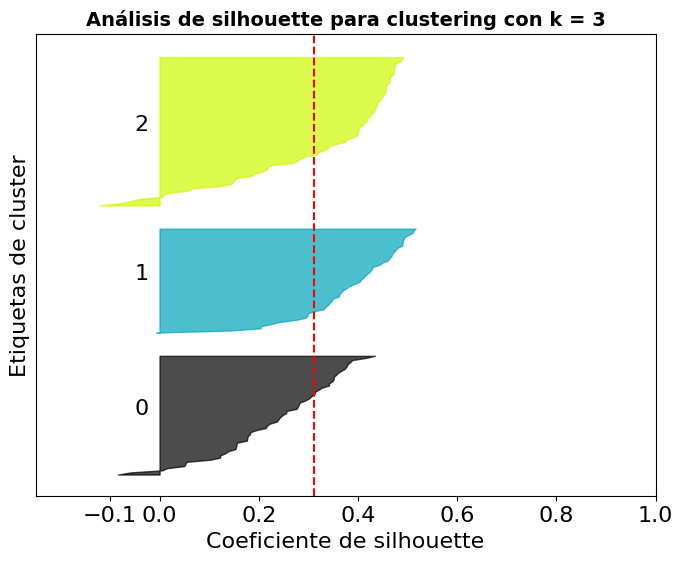

In [ ]:
k = 3
KM = KMedoids(n_clusters=k, metric='precomputed', method='fasterpam',
              init='build', random_state=0).fit(d_wine)
grafica_silhouette(KM, d_wine)

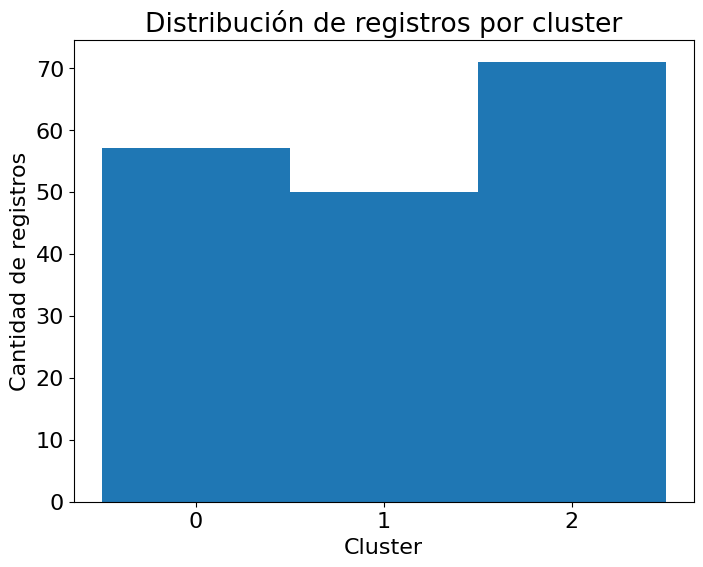

In [ ]:
plt.hist(KM.labels_,bins=k,range=[-0.5,k-0.5])
plt.xticks(np.arange(0,k))
plt.xlabel('Cluster')
plt.ylabel('Cantidad de registros')
plt.title('Distribución de registros por cluster')
plt.show()

## Comparación con las etiquetas verdaderas
Como conocemos la clase real de cada vino, podemos usarla como validación **externa**: comparamos las particiones de los dos algoritmos (jerárquico y PAM) contra las etiquetas verdaderas con el índice de Van Dongen y el ARI.

In [ ]:
ct_pam = pd.crosstab(labels_target, KM.labels_)
ct_pam

col_0,0,1,2
label,,,
0,0,0,59
1,57,2,12
2,0,48,0


In [ ]:
ct_jer = pd.crosstab(labels_target,labels_jer)
ct_jer

col_0,1,2,3
label,,,
0,0,59,0
1,2,3,66
2,48,0,0


#### Visualización 2D (validación externa)
Proyectamos las distancias a 2D con **MDS** y comparamos, lado a lado, las etiquetas verdaderas con las que encontró cada algoritmo. Así *vemos* qué tan bien recupera cada método los cultivares reales.

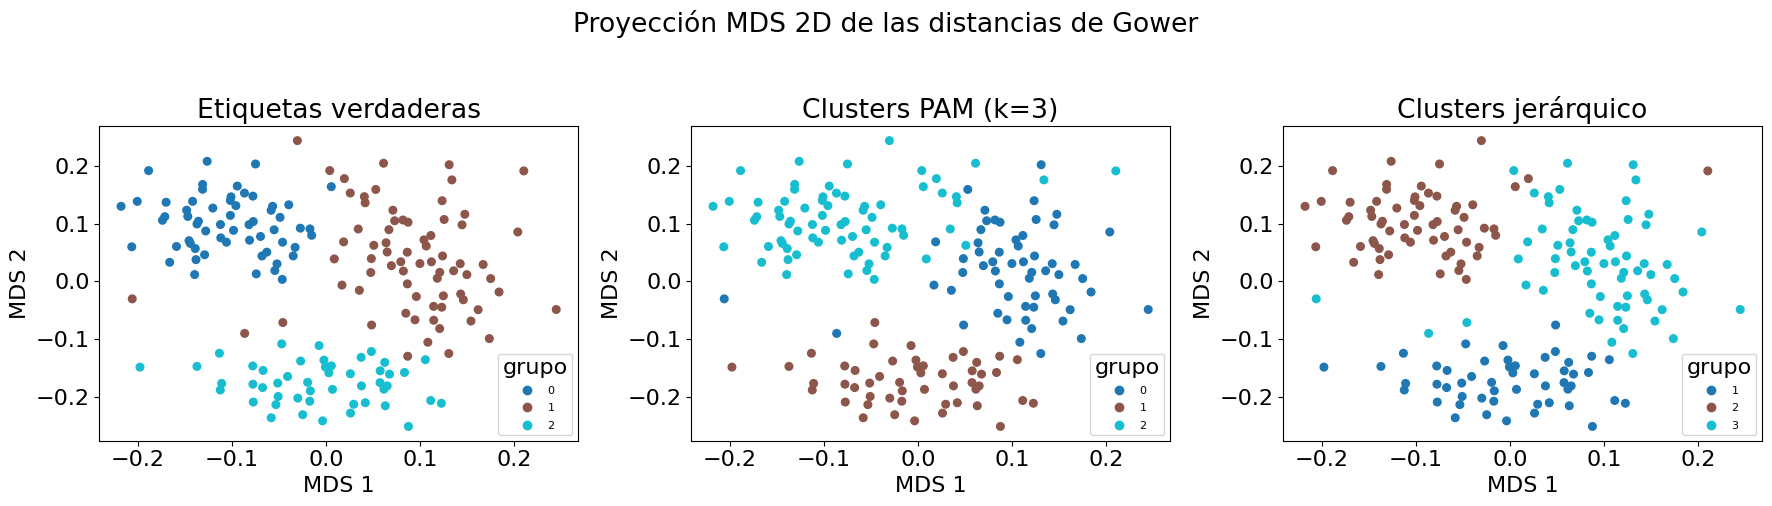

In [ ]:
from sklearn.manifold import MDS
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # MDS está migrando su API entre versiones de sklearn
    emb = MDS(n_components=2, dissimilarity='precomputed', random_state=0).fit_transform(d_wine)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, etiquetas, titulo in [
        (axes[0], labels_target, 'Etiquetas verdaderas'),
        (axes[1], KM.labels_, 'Clusters PAM (k=3)'),
        (axes[2], labels_jer, 'Clusters jerárquico')]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=etiquetas, cmap='tab10', s=30)
    ax.set_title(titulo); ax.set_xlabel('MDS 1'); ax.set_ylabel('MDS 2')
    ax.legend(*sc.legend_elements(), title='grupo', fontsize=8)
plt.suptitle('Proyección MDS 2D de las distancias de Gower', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
def vanDongen(ct):
    n2=2*(sum(ct.apply(sum,axis=1)))
    sumi = sum(ct.apply(np.max,axis=1))
    sumj = sum(ct.apply(np.max,axis=0))
    maxsumi = np.max(ct.apply(sum,axis=1))
    maxsumj = np.max(ct.apply(sum,axis=0))
    vd = (n2 - sumi - sumj)/(n2 - maxsumi - maxsumj)
    return vd

In [ ]:
print("Van Dongen para la  partición generada con el clustering jerárquico y las etiquetas es de ""%0.4f." % vanDongen(ct_jer))
print("Van Dongen para la  partición generada con el clustering PAM y las etiquetas es de ""%0.4f." % vanDongen(ct_pam))

Van Dongen para la  partición generada con el clustering jerárquico y las etiquetas es de 0.0457.
Van Dongen para la  partición generada con el clustering PAM y las etiquetas es de 0.1308.


In [ ]:
from sklearn.metrics import adjusted_rand_score

In [ ]:
print("ARI para la partición generada con el clustering jerárquico y las etiquetas es de ""%0.4f. " % adjusted_rand_score(labels_target, labels_jer))
print("ARI para la  partición generada con el clustering PAM y las etiquetas es de ""%0.4f." % adjusted_rand_score(labels_target, KM.labels_ ))

ARI para la partición generada con el clustering jerárquico y las etiquetas es de 0.9134. 
ARI para la  partición generada con el clustering PAM y las etiquetas es de 0.7691.


#### ¿Qué nos dicen estos números?
El **ARI** vale 1 si la partición coincide con las clases reales y ~0 si coincide solo lo esperable por azar; el **índice de Van Dongen** es 0 cuando coinciden y crece hacia 1 al diferir. En esta corrida el **clustering jerárquico (Ward) recupera los cultivares bastante mejor que PAM** (ARI más alto), pese a que ninguno de los dos vio las etiquetas: la composición química de los vinos refleja en buena medida su cultivar de origen.